In [8]:
import yaml

def parse_conversation(filename):
    with open(filename, "r") as f:
        doc = yaml.safe_load(f)

    peers = {p["peer"]: (p["host"], p["port"]) for p in doc["peers"]}
    packets = sorted(doc["packets"], key=lambda p: p["packet"])

    messages = []
    current_data = bytearray()
    last_role = "client"
    
    for pkt in packets:
        peer_id = pkt["peer"] 
        role = "server" if pkt["peer"] == 1 else "client"
        data = pkt["data"]  # !!binary already gives bytes
        
        if role == last_role:
            # more data
            current_data = current_data + data
        else:
            # new role, add last chunk and advance
            messages.append((last_role,current_data))
            current_data = bytearray(data)
            last_role = role

    messages.append((role,current_data))
    return messages

In [9]:
def xor(a,b):
    return bytearray([x^y for x,y in zip(a,b)])

data = parse_conversation("tcp0.yaml")
roles,data_chunks = list(zip(*data))

messages = {
    "ClientKeyExchange" : data_chunks[0],
    "ServerKeyExchange" : data_chunks[1],
    "FileLength" : data_chunks[2][:8], # RECV: IC=0 -> IC=1
    "FileData" : data_chunks[2][8:], # RECV: IC=1 -> IC=N+1
    "EchoData" : data_chunks[3], # SEND: IC=0 -> IC=N
    "TransferStatus" : data_chunks[4], # RFC IC=N+1 -> IC=N+2
}

messages

{'ClientKeyExchange': bytearray(b'\xf4\xd2\xea\x0b\xd3\x1d\xd3t7\xd1K\xdb\x13\xb9S\xb1\xdf\\\xad\xf5\xe5\x7f5\xef)\xe8\xd4\xbc\xde{\x10I'),
 'ServerKeyExchange': bytearray(b'!b\xeb\x04\xc0B\x96{\xdb\xee\xeb\x12V\xaca\x02\x9f\x18\xdb\xe7r\x7f\xa6K\x17\xff\x7f\xa6\x08y\x03\x0f'),
 'FileLength': bytearray(b'~\xa8\xec\x95)CP,'),
 'FileData': bytearray(b'\xb2{\'\xed\xa4\xfe\xb7\xcc\xf8\xde\x81D|=\x02\xc6c\x1d3S\x88\xe7J,c\'\x91\xcaW1q\x00u\xdb\xcd\xd7\x81\x10\x1f^\xe7\x1a\x8b\xe8x\xf4[\x92*\x12\x84\xaa\x7f\x8b\x9fy\xa4\x10`8\xbc\x13V\xf7\xe9\x05\xa6>\xe9~\xa8\x11\x86Yjik\xb8:$\x95\x1a\xc5\xe5A\x85\x08\xc2\x95\xf8\xc7f\xc1\xba\xb4C:P\x8d\xbcS\x88&i\x81\x1c\xa2t6\xa0Co+\xe6vR\xc6\r\x93\xadV\x07\x0ci^\x0b05\x84\xf0\x13Q\x1b\xc5\xb3\xc8\x80\xba\xd2\xabQ\xc7\x84\xb3j\xb0\xf05\xdb_\xd3\xb7\x97\xb5q+z\x99\xd0}\xc2\x9a\xf7$\x19\xc6\xffm \xa7Ho\x0e\x19\xb4\xeeT+\x99\xa0O]\xa2\x8fN\xbc\xa8(\x023\xe4=\x7f;\xb4u\xc8\r\x84\xd0o\xf7\xf4%!\xb0?2{\x88\xae\x8a\xc9t\xdbL\x81\xf9*\'D\x9a\x1c\xa8u2\x04@;&\xaeD

In [43]:
assert (len(messages["FileData"]) == len(messages["EchoData"]))

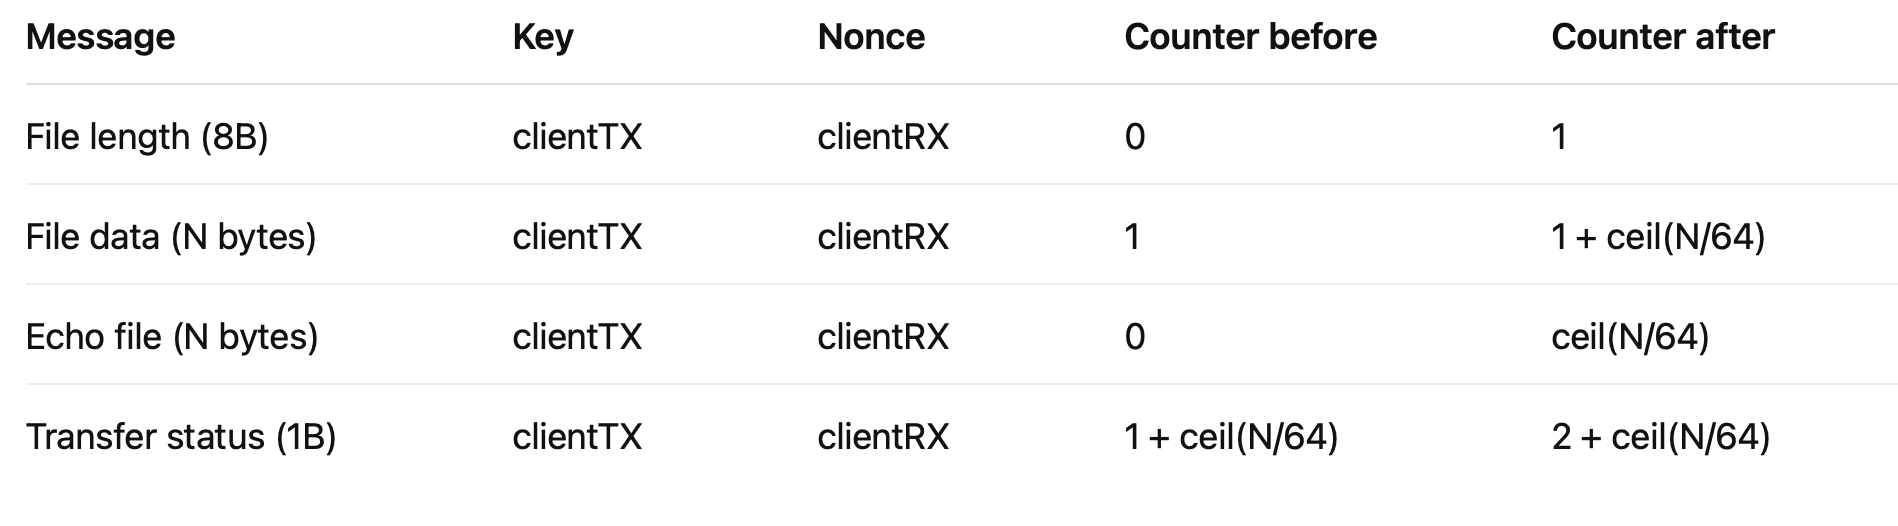

We can recover the keystream with $c \oplus m$. What information can we actually use:

- If we xor `file data` and `echo data[1:]`, we should end up with $0$ in case of $k_i \oplus m_i \oplus k_i \oplus m_i = 0$
- We know the plaintext of the `Transfer Status` which is 0. Therefore, we know that keystream but the counter is way to high.

In [44]:
xor(messages["FileLength"],messages["EchoData"])

bytearray(b'a\xf4NG\r\n\x1a\n')

So we likely have a PNG! What is the PNG header?

In [ ]:
png = b"\x89PNG\r\n\x1a\n" #	89 50 4e 47 0d 0a 1a 0a (https://en.wikipedia.org/wiki/PNG)
png.hex()

'89504e470d0a1a0a'

In [58]:
stream = xor(messages["EchoData"],png)
assert int.from_bytes(xor(messages["FileLength"],stream),"little") == len(messages["FileData"]), "We can deduct the file length!"

In [ ]:
len(messages["EchoData"]) ** 0.5

42216

<https://github.com/jedisct1/libsodium/blob/09e995c0c85a0026510704b8ce7f5867a09a3841/src/libsodium/crypto_stream/xchacha20/stream_xchacha20.c#L44C1-L54C2>
```c
int
crypto_stream_xchacha20_xor_ic(unsigned char *c, const unsigned char *m,
                               unsigned long long mlen, const unsigned char *n,
                               uint64_t ic, const unsigned char *k)
{
    unsigned char k2[crypto_core_hchacha20_OUTPUTBYTES];

    crypto_core_hchacha20(k2, n, k, NULL);
    return crypto_stream_chacha20_xor_ic(
        c, m, mlen, n + crypto_core_hchacha20_INPUTBYTES, ic, k2);
}
```

which calls to `chacha20` but only changes the nonce! As they key and nonce are the same, this should not have any effect. Therefore, we need to look at `chacha20`. It points to

```c
static int
stream_ref_xor_ic(unsigned char *c, const unsigned char *m,
                  unsigned long long mlen, const unsigned char *n, uint64_t ic,
                  const unsigned char *k)
{
    struct chacha_ctx ctx;
    uint8_t           ic_bytes[8];
    uint32_t          ic_high;
    uint32_t          ic_low;

    if (!mlen) {
        return 0;
    }
    ic_high = U32V(ic >> 32);
    ic_low  = U32V(ic);
    STORE32_LE(&ic_bytes[0], ic_low);
    STORE32_LE(&ic_bytes[4], ic_high);
    chacha_keysetup(&ctx, k);
    chacha_ivsetup(&ctx, n, ic_bytes);
    chacha20_encrypt_bytes(&ctx, m, c, mlen);
    sodium_memzero(&ctx, sizeof ctx);

    return 0;
}
```

So what does this all mean: 

$c_{send} = p_0 \oplus E_{k}(ibc=1) || p_1 \oplus E_{k}(ibc=2) || \dots $

$c_{recv} = p_0 \oplus E_{k}(ibc=0) || p_1 \oplus E_{k}(ibc=1) || \dots$

Chacha operates on $512$ bits which are $64$ bytes. Therefore, the same keystream is in BOTH ciphertext, but shifted. Each $p_i$ is $64$ bytes such that $c_{send}[i]$ and $c_{recv}[i-64]$ share the key. 

We know the first $8$ bytes of $p_0$ and therefore $E_{k}(ibc=0)$ and $E_{k}(ibc=1)$. However, the full keystream of $E_{k}(ibc=1)$ is in $c_{send}$ and $c_{recv}$! So likely, we will loose the 

In [2]:
PNG_header = b"\x89PNG\r\n\x1a\n" 
IHDR_header = bytes.fromhex("00 00 00 0d 49 48 44 52") # SIZE|IHDR
WIDTH = bytes.fromhex("00 00 00 03") # WIDTH
HEIGHT = bytes.fromhex("00 00 00 03") # HEIGHT
BITDEPTH = bytes.fromhex("08") # 1 byte, values are powers of to {1, 2, 4, 8, or 16}
COLOR = bytes.fromhex("02") # 1 byte, values are {0, 2, 3, 4, or 6}, assuming RGB
CFI = bytes.fromhex("00 00 00") # compression, filter method, interlace method

"""
The CRC is computed over the chunk type code (4 bytes)
and the chunk data (variable length).
The length field itself is excluded from the CRC calculation.
Each byte of this combined data is processed, typically from the least significant bit
to the most significant bit.
"""

CRC = bytes.fromhex("00 00 00 00") # CRC over the fields

end = bytes.fromhex("00 00 00 00 49 45 4e 44 ae 42 60 82")# LENGTH|IEND|CRC of that


partial = (
    PNG_header,
    IHDR_header,
    WIDTH,
    HEIGHT,
    BITDEPTH,
    COLOR,
    CFI,
    CRC,
)

p0 = bytearray()

for b in partial:
    p0 += b

len(p0)

33

In [10]:
plaintext = (64) * ["?"]

partial = (
    (PNG_header,"X"),
    (IHDR_header,"X"),
    (WIDTH,"W"),
    (HEIGHT,"H"),
    (BITDEPTH,"B"),
    (COLOR,"C"),
    (CFI,"X"),
    (CRC,"Z"),
)

last = 0
for info,status in partial:
    marker = (status) * len(info) 
    plaintext[last:last+len(info)] = marker
    last += len(info) 

know_IEND_start = (len(messages["EchoData"]) % 64) - len(end)
know_IEND_end = know_IEND_start + len(end)

for i in range(know_IEND_start,know_IEND_end):
    if plaintext[i] == "Z":
        plaintext[i] = "[Z]"
    else:
        plaintext[i] = "X"

print("".join(plaintext))

XXXXXXXXXXXXXXXXWWWWHHHHBCXXX[Z][Z][Z][Z]XXXXXXX????????????????????????


# Let's first try to recover the plaintext from the HEADER and the END 

In [116]:
from itertools import batched

def retainedXor(a,b):
    al = len(a)
    bl = len(b)
    pad = b"\x00" * abs(bl-al)
    
    if al > bl:
        return xor(a,b+pad)
    else:
        return xor(a+pad,b)

send = list(batched(messages["FileData"],n=64))
recv = list(batched(messages["EchoData"],n=64))

canceled_keys = zip(
    send, # # p_0 xor E(1) | p_1 xor E(2) | ...
    recv[1:] # p_1 xor E(1) | p_2 xor E(2) | ...
)
canceled_keys = list(map(
    lambda comb: xor(comb[0],comb[1]),canceled_keys # p_0 XOR p_1 | p_1 xor p_2 | p_2 xor p_3
))

relativeP0 = [canceled_keys[0]] # p_0 xor p_1 || p_0 xor p_2 || p_0 xor p_3
for plaintexted_xor in canceled_keys[1:]:
    relativeP0.append(
        xor(relativeP0[-1],plaintexted_xor) # p_0 XOR p_1 xor p_1 xor p_2 = p_0 xor p_2
    )

In [168]:
# Pure static information from the start
PNG_HEADER = b"\x89PNG\r\n\x1a\n"
IDHR_HEADER = bytes.fromhex("00 00 00 0d 49 48 44 52") # SIZE|IHDR
START_HEADER = PNG_HEADER + IDHR_HEADER

# compute the IEND part to apply that to relativeP0
IEND_HEADER = bytes.fromhex("00 00 00 00 49 45 4e 44 ae 42 60 82")# LENGTH|IEND|CRC of that
start_position = len(canceled_keys[-1]) - len(IEND_HEADER)
last = xor(canceled_keys[-1][start_position:start_position+len(IEND_HEADER)],IEND_HEADER)

for plaintexted_xor in canceled_keys[-2::-1]: # skip the last one and reverse
    last = xor(
        plaintexted_xor[start_position:start_position+len(IEND_HEADER)],
        last
    )

assert len(last) == len(IEND_HEADER)
assert start_position >  len(IDHR_HEADER)

p0Known = bytearray(b"\x00" * 64)
print(p0Known)
p0Known[:len(START_HEADER)] = xor(p0Known[:len(START_HEADER)],START_HEADER)
print(p0Known)
p0Known[start_position:start_position+len(IEND_HEADER)] = xor(p0Known[start_position:start_position+len(IEND_HEADER)],last)
print(p0Known)

bytearray(b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00')
bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00')
bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00g\xb1V\x14\x00\x00\x05\x1diTX\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00')


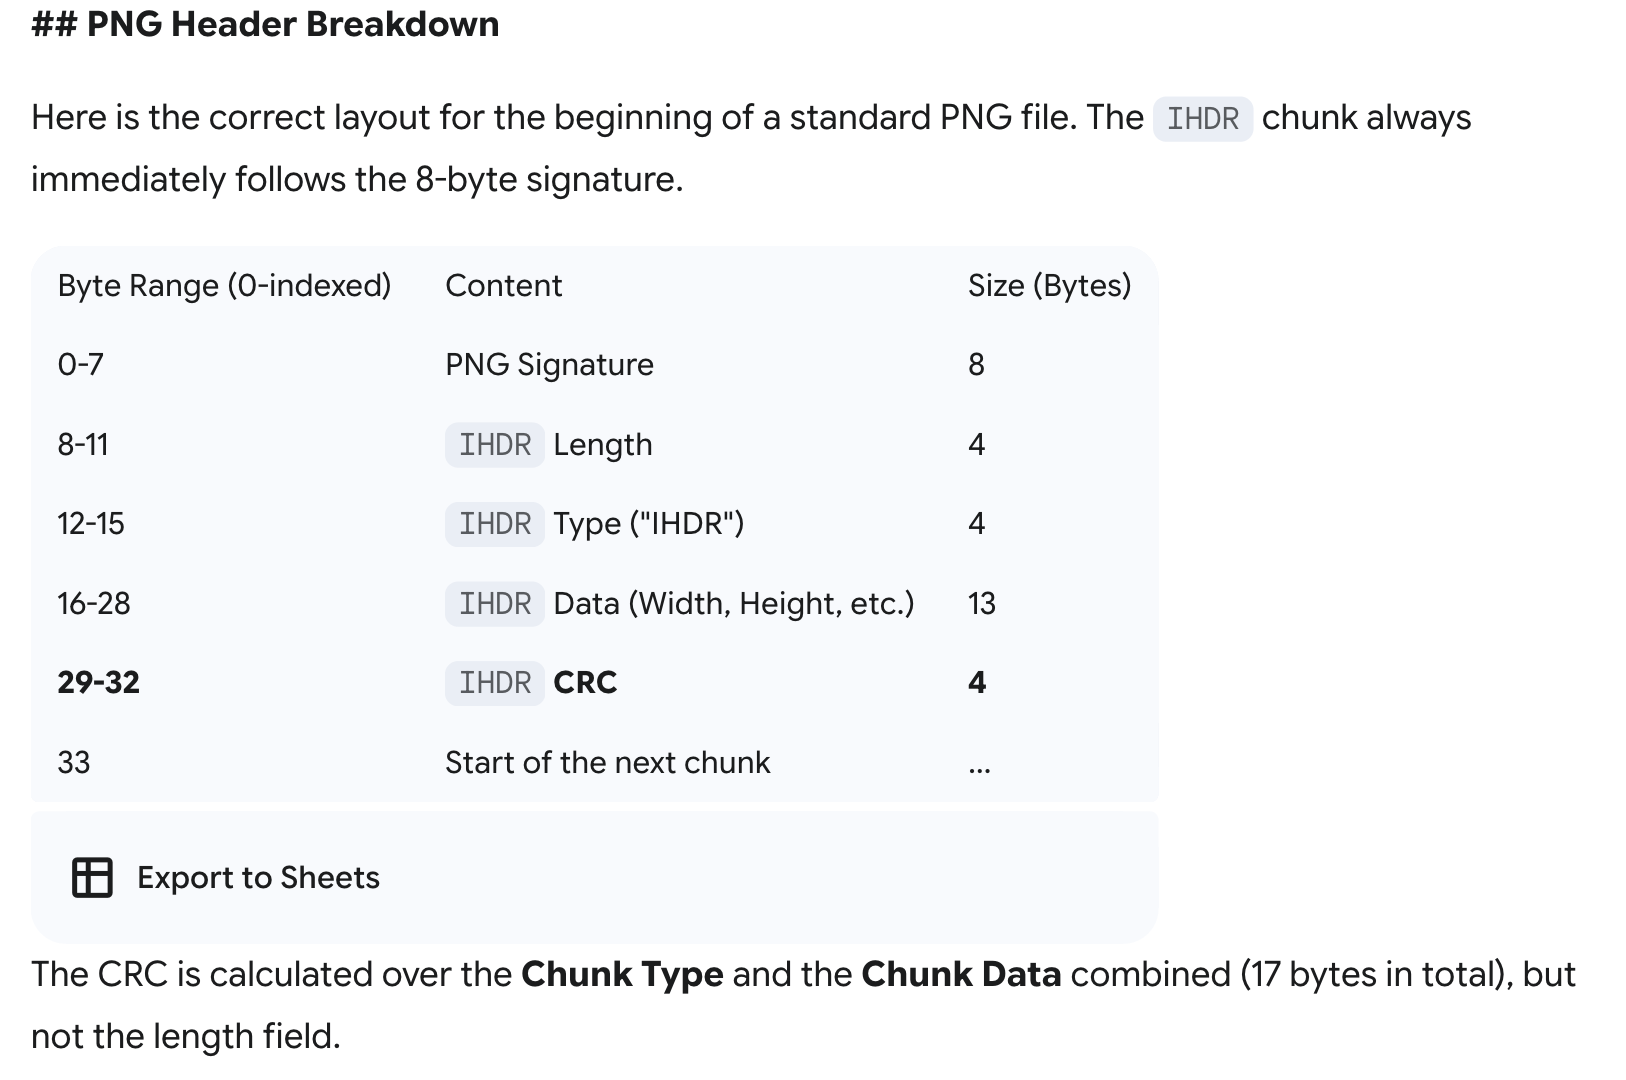

In [166]:
known_crc_bytes = p0Known[29:29+4]
known_crc_bytes.hex()

'67b15614'

In [167]:
import zlib
import struct

def find_ihdr_candidates(target_crc_bytes, max_dim=0x0FFF):
    """
    Searches for PNG IHDR candidates that match a given CRC32 checksum.
    """
    print(f"[*] Starting grid search for IHDR with target CRC: {target_crc_bytes.hex()}")
    
    chunk_type = b"IHDR"
    valid_candidates = []
    
    # Common bit depths for PNG files
    valid_bit_depths = [1, 2, 4, 8, 16]
    
    # Common PNG color types
    valid_color_types = [0, 2, 3, 4, 6]

    for width in range(1, max_dim + 1):
        for height in range(1, max_dim + 1):
            for bit_depth in valid_bit_depths:
                for color_type in valid_color_types:
                    
                    # Pack the IHDR data: width, height, bit_depth, color_type,
                    # compression(0), filter(0), interlace(0)
                    data = struct.pack(">IIBBBBB", 
                                       width, height, bit_depth, 
                                       color_type, 0, 0, 0)
                    
                    # Calculate CRC32 for the chunk type + data
                    crc = zlib.crc32(chunk_type + data)
                    
                    # Compare the calculated CRC with the target
                    if crc == struct.unpack(">I", target_crc_bytes)[0]:
                        candidate = {
                            "width": width,
                            "height": height,
                            "bit_depth": bit_depth,
                            "color_type": color_type,
                            "ihdr_data": data
                        }
                        valid_candidates.append(candidate)
                        print(f"[+] Found matching candidate: {candidate}")

    if not valid_candidates:
        print("[-] No matching candidates found.")
        
    return valid_candidates

find_ihdr_candidates(known_crc_bytes)

[*] Starting grid search for IHDR with target CRC: 67b15614
[+] Found matching candidate: {'width': 1920, 'height': 1080, 'bit_depth': 8, 'color_type': 2, 'ihdr_data': b'\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00'}
[+] Found matching candidate: {'width': 2302, 'height': 2157, 'bit_depth': 4, 'color_type': 4, 'ihdr_data': b'\x00\x00\x08\xfe\x00\x00\x08m\x04\x04\x00\x00\x00'}


[{'width': 1920,
  'height': 1080,
  'bit_depth': 8,
  'color_type': 2,
  'ihdr_data': b'\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00'},
 {'width': 2302,
  'height': 2157,
  'bit_depth': 4,
  'color_type': 4,
  'ihdr_data': b'\x00\x00\x08\xfe\x00\x00\x08m\x04\x04\x00\x00\x00'}]

The secon one has an invalid depth due to grayscale.

In [182]:
assert (28-16+1) == 13
assert len(b"\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00") == 13

p0KnownWithIHDR = bytearray(p0Known)
p0KnownWithIHDR[16:29] = b'\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00'

In [183]:
p0KnownWithIHDR

bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00g\xb1V\x14\x00\x00\x05\x1diTX\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00')

In [184]:
result = bytearray(p0KnownWithIHDR)
for plaintextp0 in relativeP0:
    assert len(plaintextp0) >= len(plaintextp0)
    result += xor(plaintextp0,p0KnownWithIHDR)

In [185]:
with open("flag2.png","wb") as f:
    f.write(result)

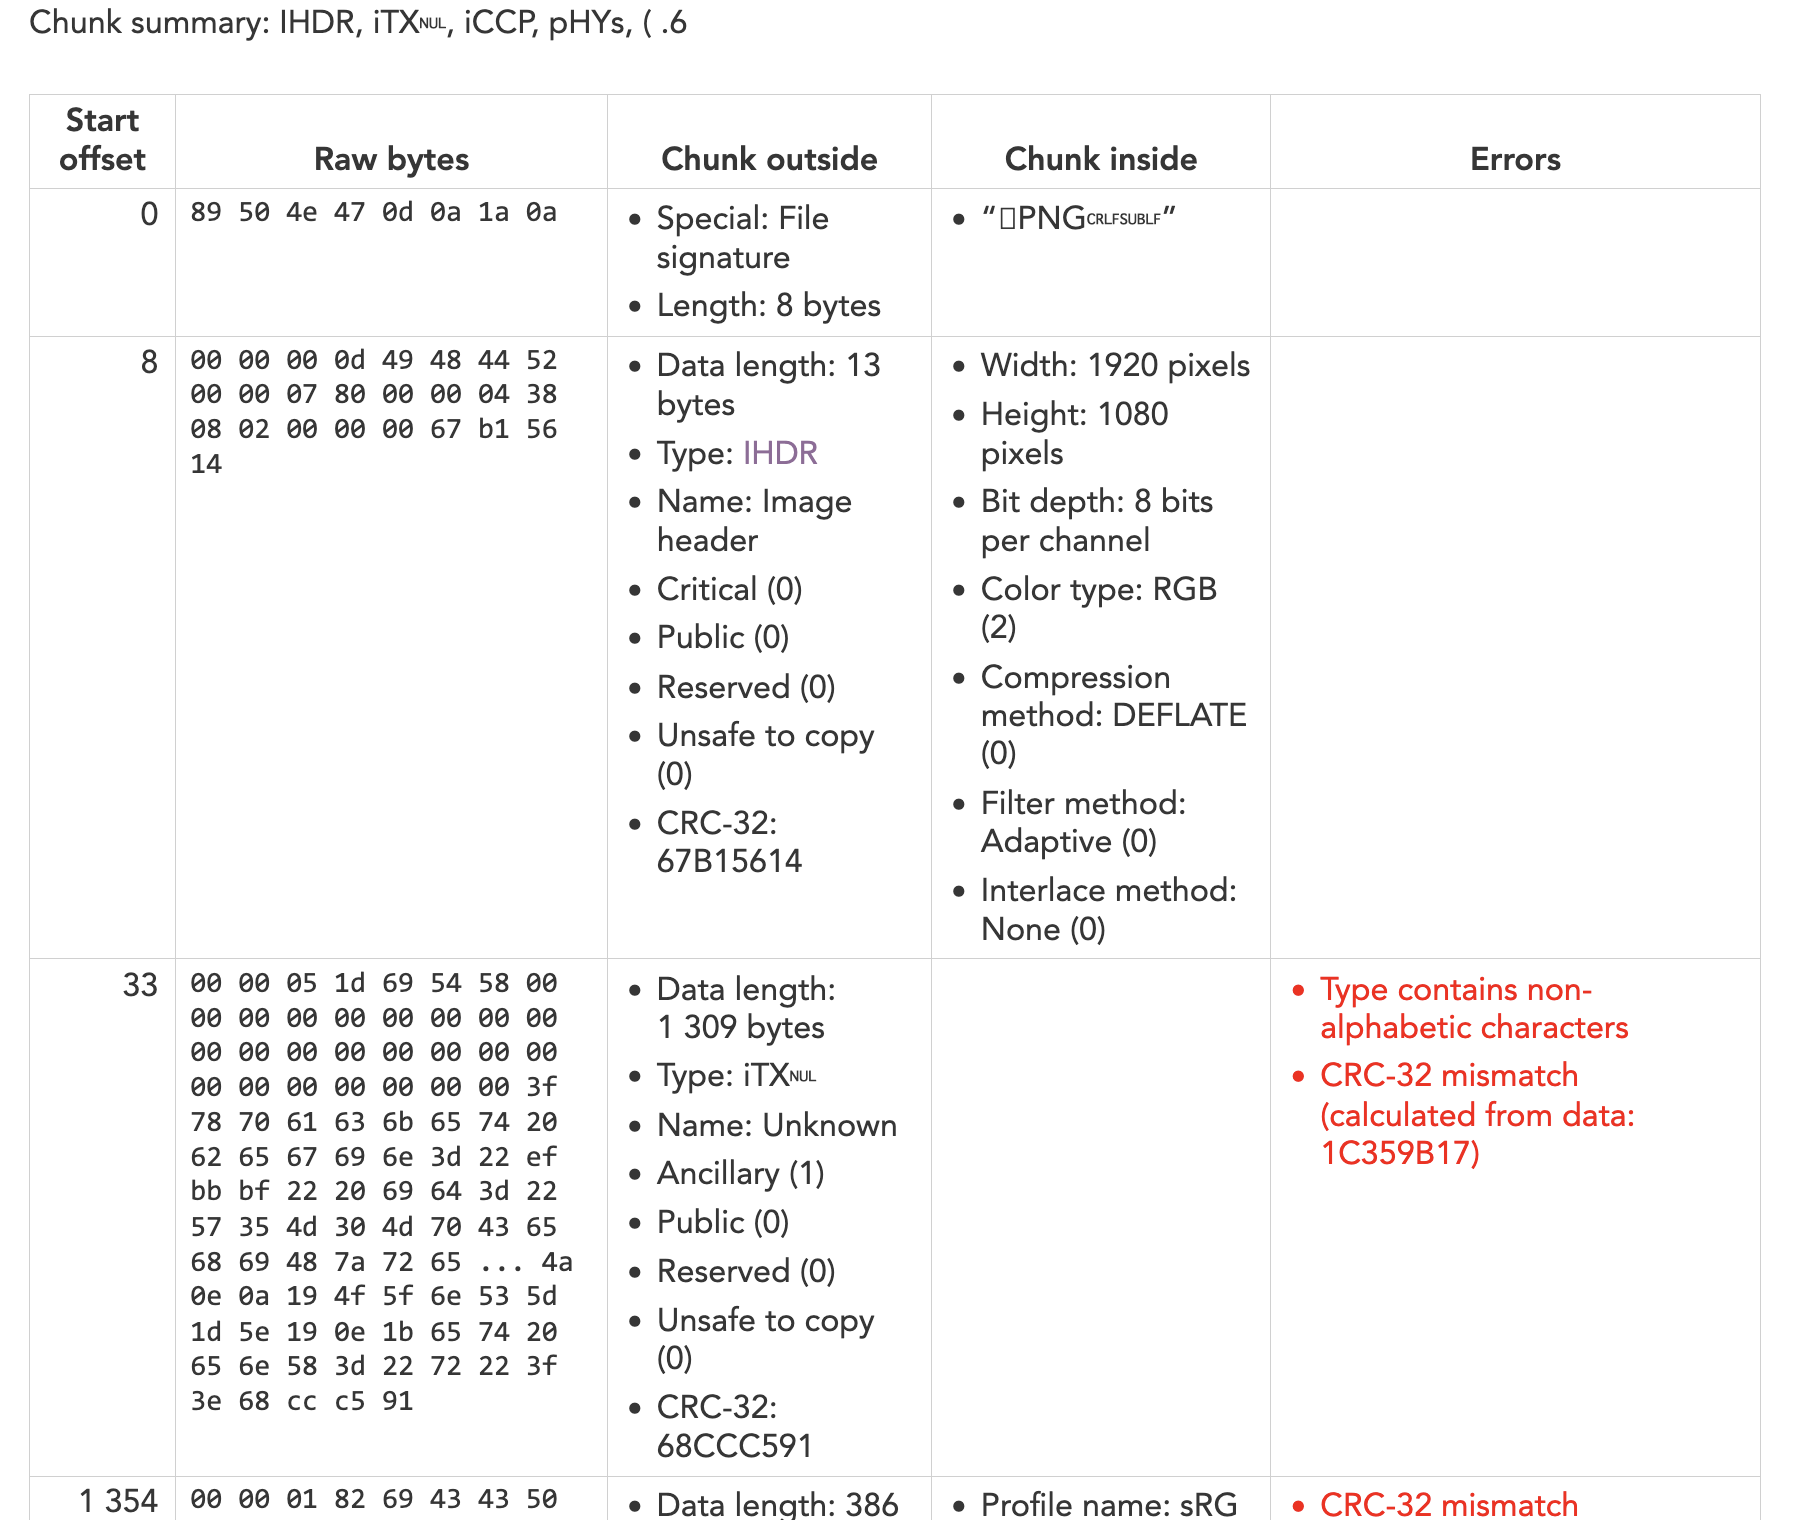

So far, we have covered the first 40 bytes, so 24 missing:

In [187]:
mask = "XXXXXXXXXXXXXXXXWWWWHHHHBCCCXXXX[Z][Z][Z][Z]XXXX????????????????????????"

64 - mask.count("?")

40

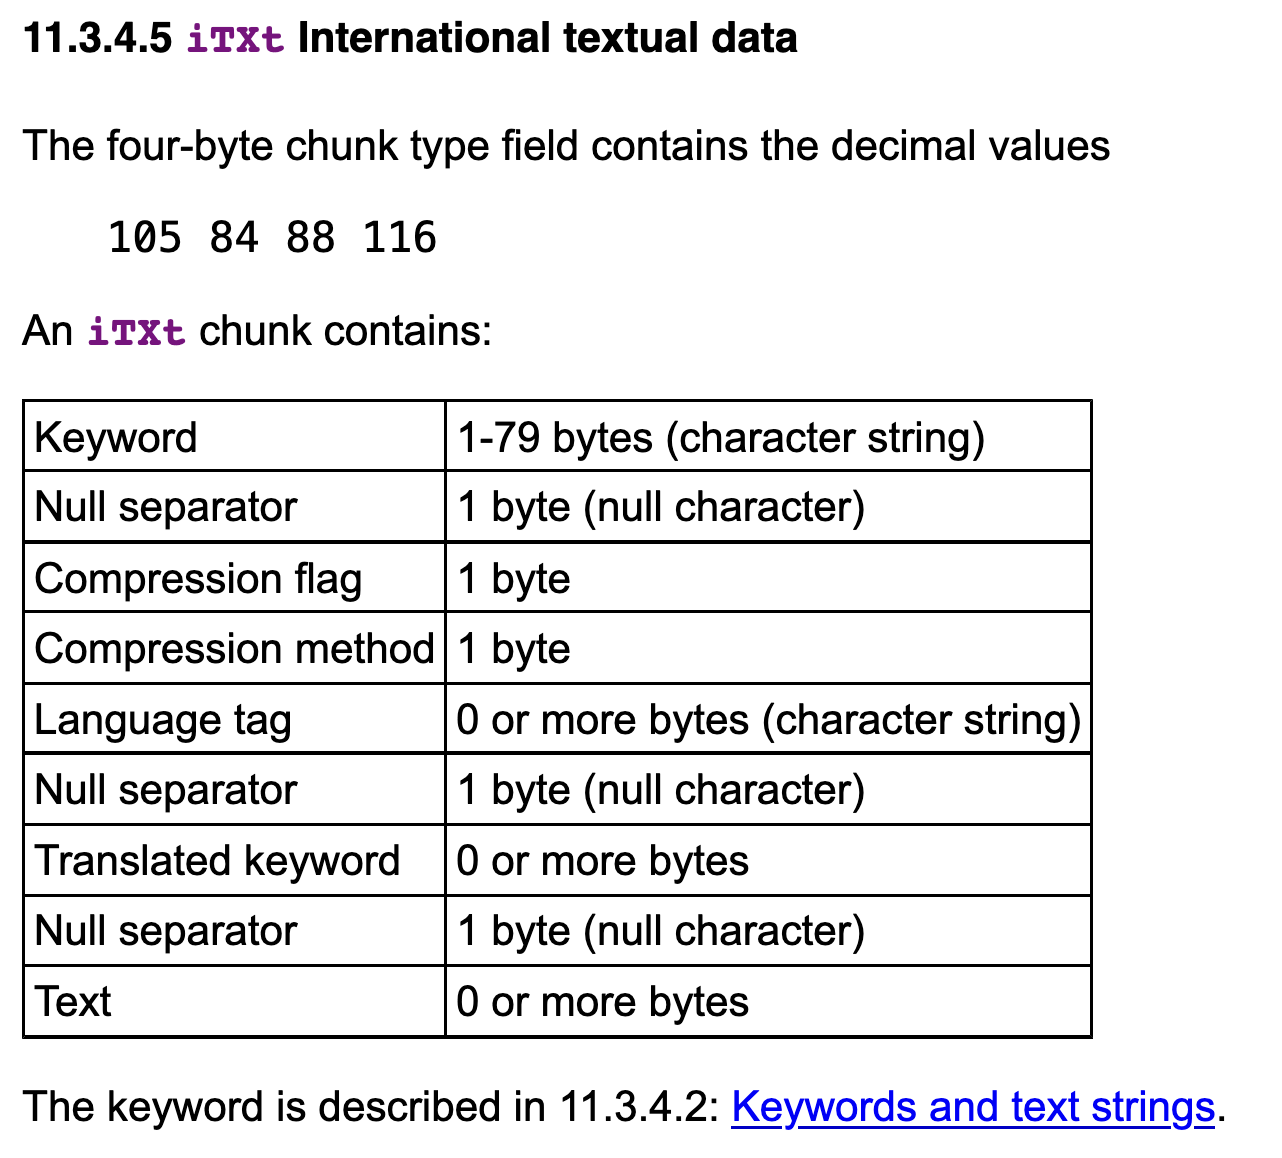

it seems like the next chunk is just a text chunk!

In [257]:
p0KnowniTXT = bytearray(p0KnownWithIHDR)
start_itxt = p0KnowniTXT.index(b"iTX")
crib = b"iTXt"

assert start_itxt == 33 + 4

p0KnowniTXT[start_itxt:start_itxt + len(crib)] = crib
start_itxt += len(crib)

assert start_itxt == 37 + 4 # 41

In [225]:
from PIL import Image
import io

In [ ]:
p0KnowniTXT = bytearray(p0KnownWithIHDR)
start_itxt = p0KnowniTXT.index(b"iTX")
crib = b"iTXt"

assert start_itxt == 33 + 4

p0KnowniTXT[start_itxt:start_itxt + len(crib)] = crib
start_itxt += len(crib)

assert start_itxt == 37 + 4 # 41

# Lets try all keywords
keywords = [
    b"Title",
    b"Author",
    b"Description",
    b"Copyright",
    b"Creation",
    b"Software",
    b"Disclaimer",
    b"Warning",
    b"Source",
    b"Comment",
]

tests = []
for keyword in keywords:
    keywordlog = bytearray(keyword).decode("ASCII")
    p0Keyword = bytearray(p0KnowniTXT)
    keyword += b"\x00" # mandatory null byte
    keyword += b"\x00" # compression flag
    keyword += b"\x00" # compression method
    keyword += b"\x00" # language tag maybe
    keyword += b"\x00" # null sep
    # translated keyword maybe
    keyword += b"\x00" # null sep
    p0Keyword[start_itxt:start_itxt + len(keyword)] = keyword


    print(start_itxt + len(keyword),":",p0Keyword)
    
    result = bytearray(p0Keyword)
    for plaintextp0 in relativeP0:
        result += xor(plaintextp0,p0Keyword)
    
    try:
        # im = Image.open(io.BytesIO(result))
        # im.verify()
        
        with open(f"generated/flag_{keywordlog}.png","wb") as f:
            f.write(result)
        print(f"{keywordlog} seems to work")
    except:
        pass

51 : bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00g\xb1V\x14\x00\x00\x05\x1diTXtTitle\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00')
Title seems to work
52 : bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00g\xb1V\x14\x00\x00\x05\x1diTXtAuthor\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00')
Author seems to work
57 : bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00g\xb1V\x14\x00\x00\x05\x1diTXtDescription\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00')
Description seems to work
55 : bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00g\xb1V\x14\x00\x00\x05\x1diTXtCopyright\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00')
Copyright seems to work
54 : bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\

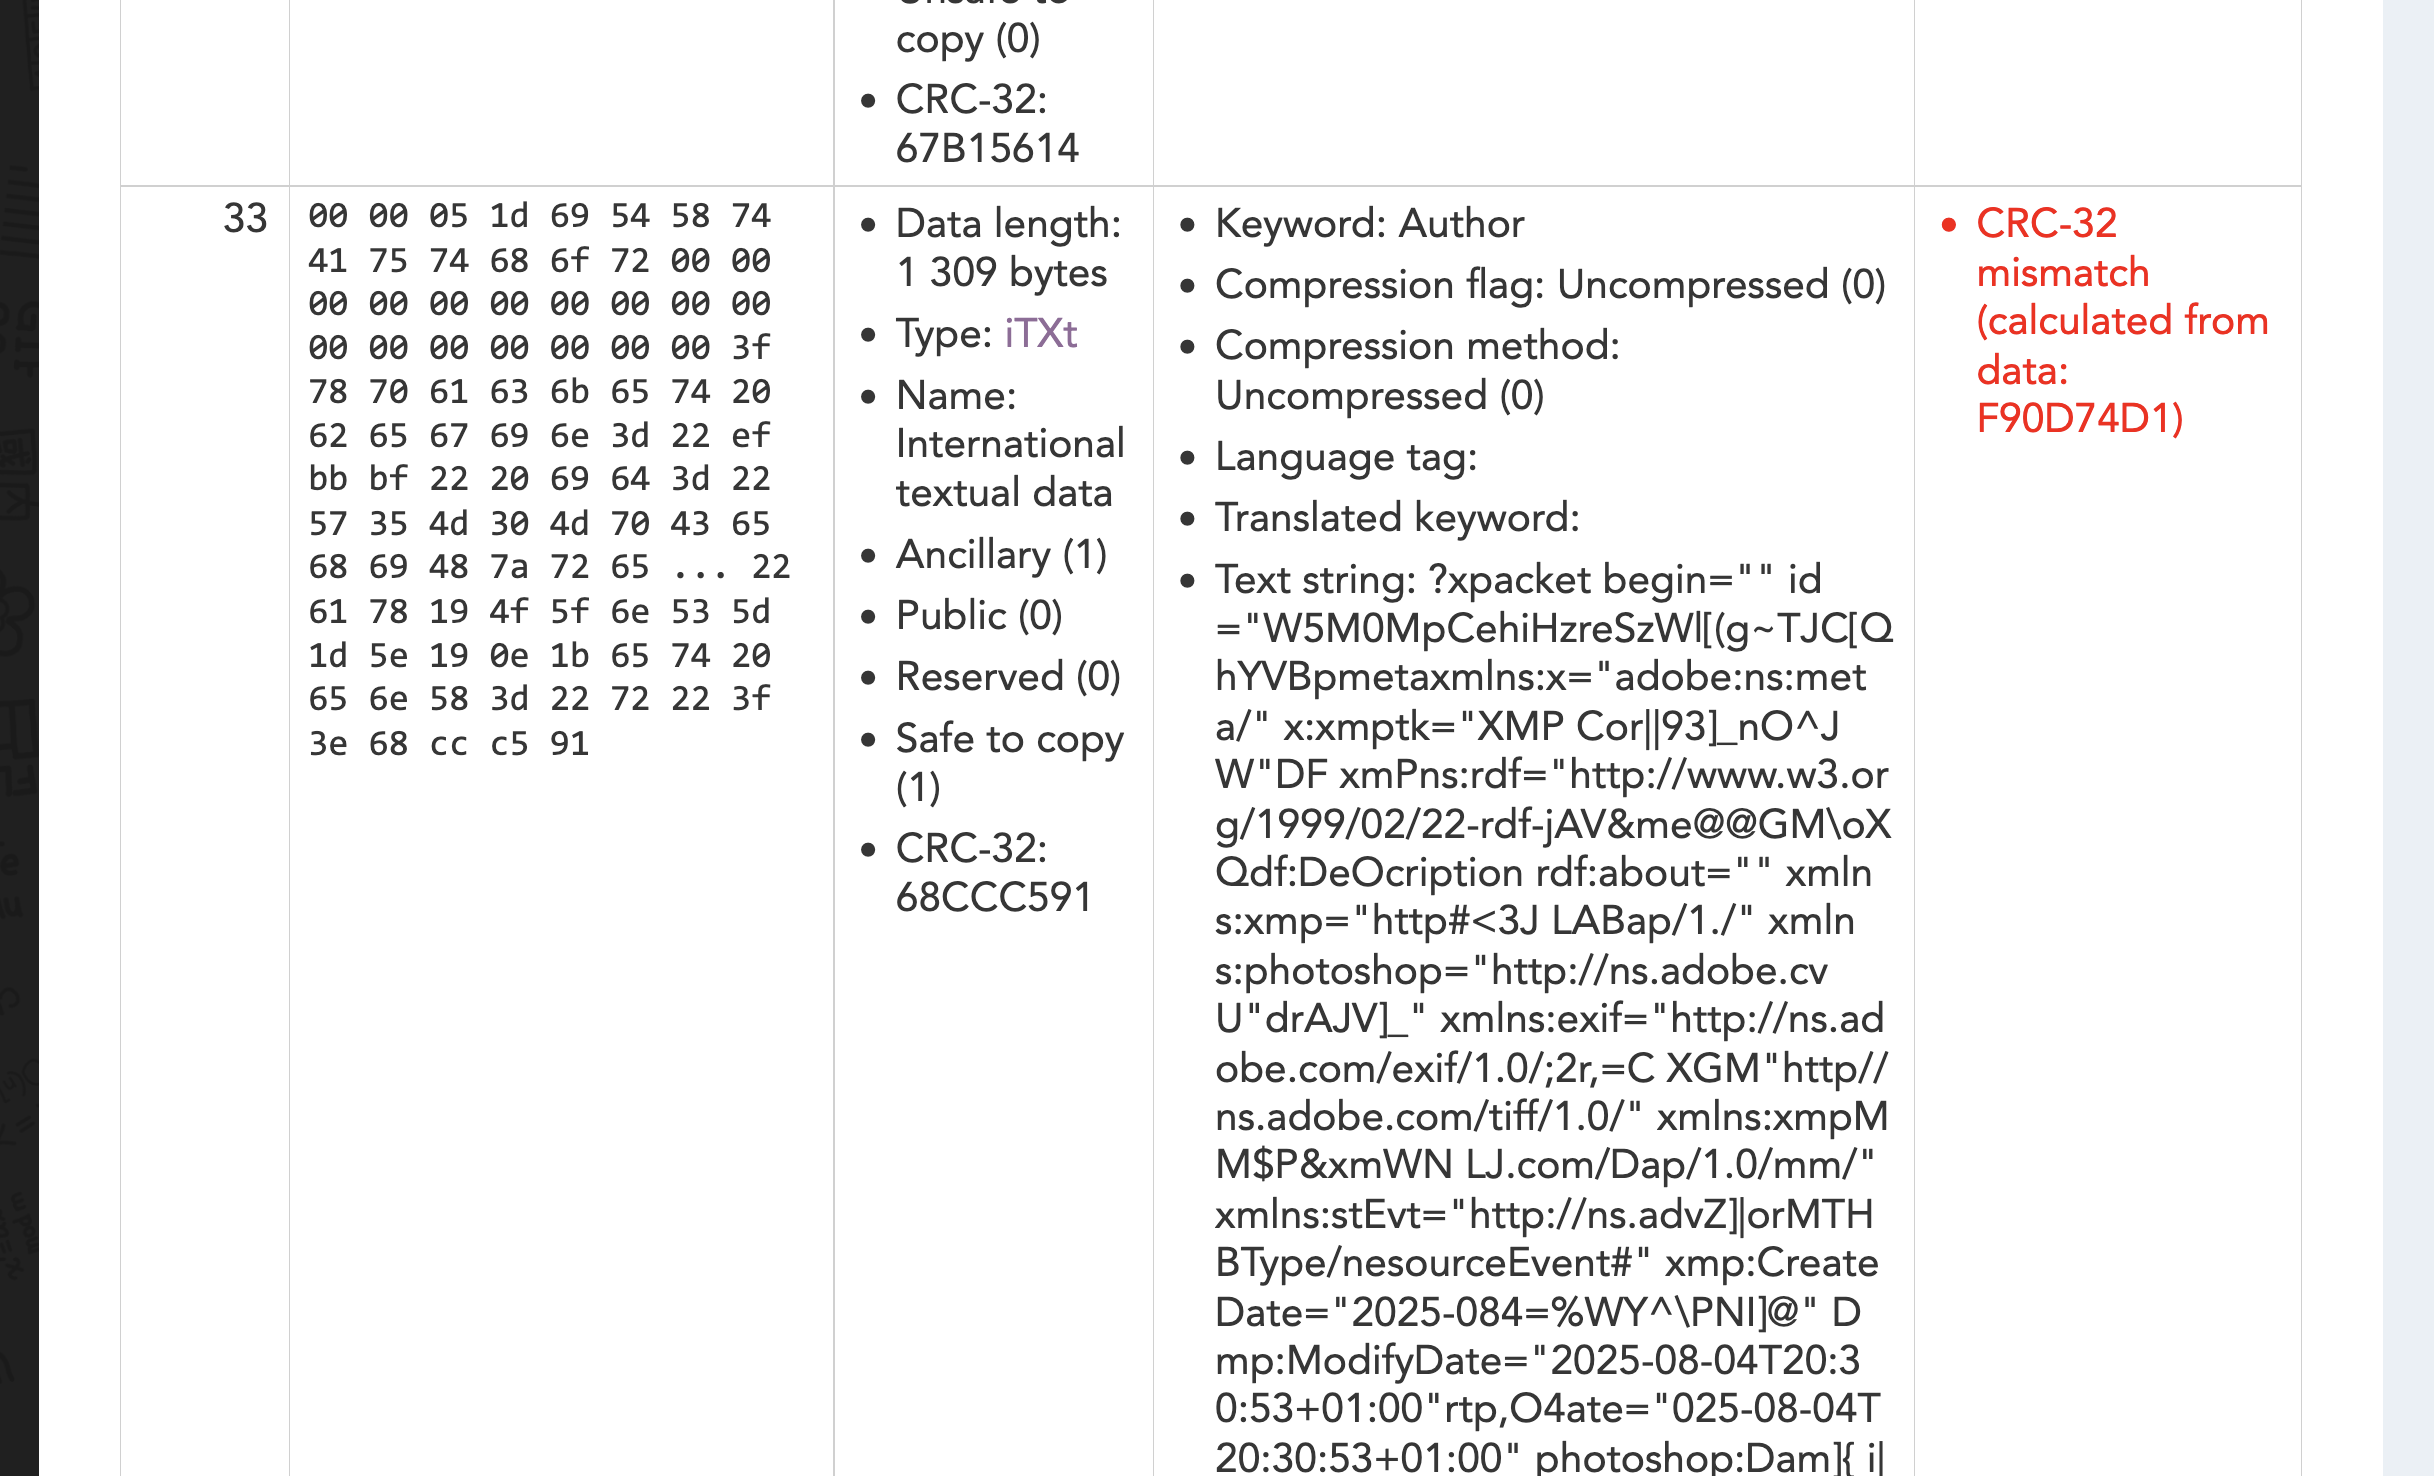

This looks like a comment at best!

In [237]:
import string

In [ ]:
p0Keyword = bytearray(p0KnowniTXT)
keyword = bytearray()
keyword += b"XML:com.adobe.xmp" 
keyword += b"\x00" # mandatory null byte
keyword += b"\x00" # compression flag
keyword += b"\x00" # compression method
keyword += b"\x00" # null sep
keyword += b"\x00" # null sep
keyword += b"<" # start of text

p0Keyword = bytearray(p0KnowniTXT)
p0Keyword[start_itxt:] = keyword
p0Keyword = p0Keyword[:64]
print(p0Keyword)

result = bytearray(p0Keyword)
for plaintextp0 in relativeP0:
    result += xor(plaintextp0,p0Keyword)

with open(f"flag.png","wb") as f:
    f.write(result)


bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00g\xb1V\x14\x00\x00\x05\x1diTXtXML:com.adobe.xmp\x00\x00\x00\x00\x00<')


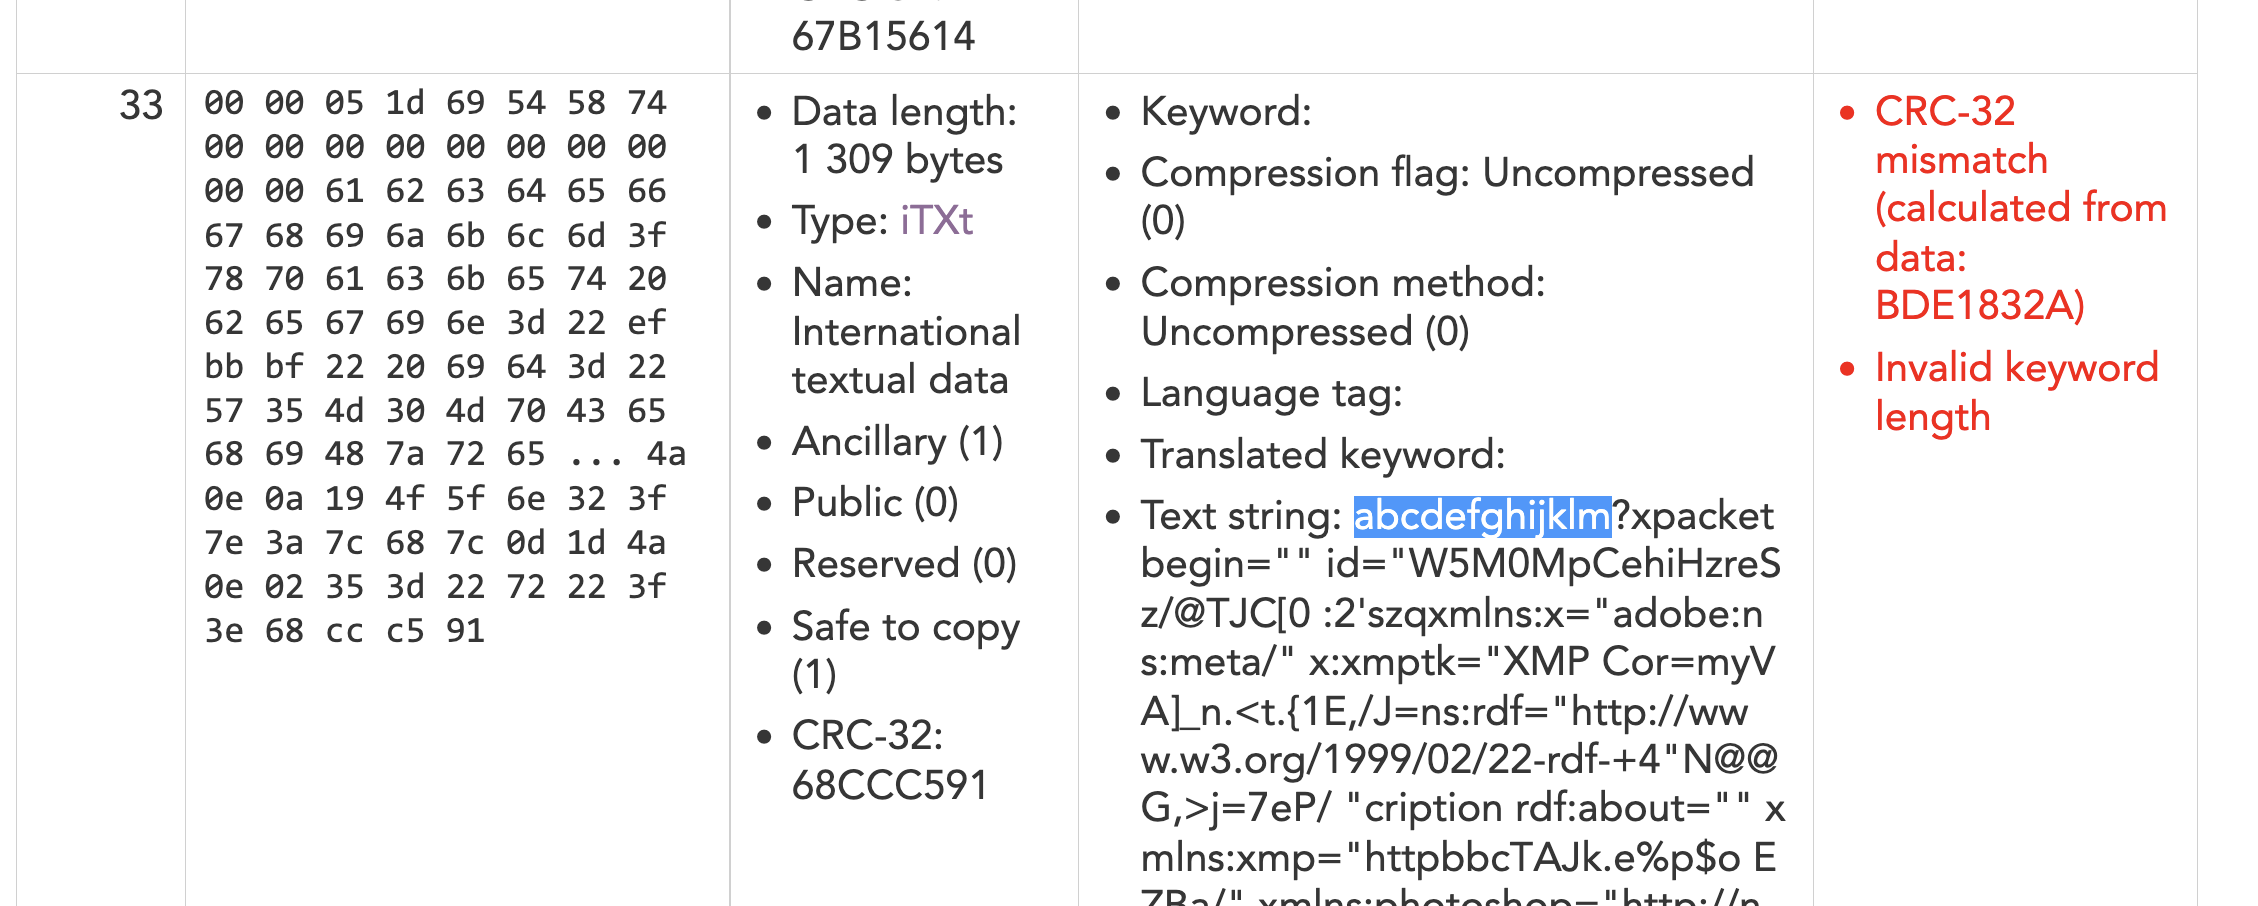

1. There must be a lang or keyword or something. The part `<?xpacket begi` is only present in the next block. We can see the last byte must be a "<"

In [272]:
divmod(160,64)

(2, 32)

We generated this:

```
canceled_keys = list(map(
    lambda comb: xor(comb[0],comb[1]),canceled_keys # p_0 XOR p_1 | p_1 xor p_2 | p_2 xor p_3
))
```

```
<?xpacket begin="﻿" id="W5M0MpCehiHzreSzNTczkc9d"?>
<x:xmpmeta xmlns:x="adobe:ns:meta/" x:xmptk="Adobe XMP Core 5.6-c138 79.159824, 2016/09/14-01:09:01">
  <rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">
    <rdf:Description rdf:about=""
      xmlns:xmp="http://ns.adobe.com/xap/1.0/"
      xmlns:dc="http://purl.org/dc/elements/1.1/"
      xmlns:photoshop="http://ns.adobe.com/photoshop/1.0/"
      xmlns:xmpMM="http://ns.adobe.com/xap/1.0/mm/"
      xmlns:stEvt="http://ns.adobe.com/xap/1.0/sType/ResourceEvent#"
      xmlns:stRef="http://ns.adobe.com/xap/1.0/sType/ResourceRef#"
      xmlns:tiff="http://ns.adobe.com/tiff/1.0/" xmlns:exif="http://ns.adobe.com/exif/1.0/">
```

In [ ]:
assert len(result[64*3:64*4]) == 64
result[64*3:64*4] # it is off, so let's recalc the key

bytearray(b'ns:rdf="http://www.w3.org/1999/02/22-rdf-h[O#gy4@\x12G,>\x0cj=7e\x0c\x0fPDes')

Chatty says: 
    
`<rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">`

but we got

`<t.{1E,/Jxmlns:rdf="http://www.w3.org/1999/02/22-rdf-h[O#gy4@\x12G,>`

In [328]:
plaintext = b'ns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">\n  <rdf:Des"'
plaintext = plaintext[:64]
plaintext

b'ns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">\n  <rdf:Des'

In [329]:
recovered_p0 = xor(plaintext,relativeP0[2])
recovered_p0

bytearray(b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00g\xb1V\x14\x00\x00\x05\x1diTXtXML:com.adobe.xmp\x00\x00\x00\x00\x00<')

`XML:com.adobe.xmp`